<a href="https://colab.research.google.com/github/arthyaroul/pilotage-risques-chantier/blob/main/pilotage-risques-chantier/notebooks/03_random_forest_et_comparaison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 · Random forest et comparaison des modèles

**Projet :** Pilotage des risques de chantier · Arthy Aroul & Aurélie Mahé · Bootcamp Data Essentials, Jedha (2026)

**Objectif :** tester un modèle plus robuste (random forest), l'optimiser, puis comparer tous les modèles du projet dans des conditions strictement identiques.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    matthews_corrcoef,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style="whitegrid")

## 1. Chargement des données

In [6]:
# Chemin du fichier (voir data/README.md pour télécharger le dataset)
# Sur Google Colab : téléverser le CSV puis utiliser "/content/bim_ai_civil_engineering_dataset.csv"
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/bim_ai_civil_engineering_dataset.csv"

df = pd.read_csv(DATA_PATH)
print(f"{df.shape[0]} projets, {df.shape[1]} variables")

1000 projets, 28 variables


## 2. Préparation des données

Mêmes choix que dans les autres notebooks, pour que les modèles soient comparés sur exactement les mêmes variables.

| Variable exclue | Raison |
|---|---|
| `Project_ID` | Identifiant, aucune information prédictive |
| `Start_Date`, `End_Date` | Dates brutes |
| `Safety_Risk_Score` | **Fuite de données** : `Risk_Level` est dérivé de ce score (voir EDA) |
| `Crack_Width`, `Image_Analysis_Score` | Doublons d'information du score de risque |
| `Risk_Level` | Variable cible |

On conserve donc 21 variables explicatives (3 catégorielles, 18 numériques). `Anomaly_Detected` est gardée, mais reste à surveiller : aucun projet « Low » n'a d'anomalie détectée, ce qui laisse penser qu'elle pourrait être liée au calcul du risque.

In [7]:
target_col = "Risk_Level"
drop_cols = [
    "Project_ID", "Start_Date", "End_Date",           # identifiant et dates brutes
    "Safety_Risk_Score",                              # fuite de données
    "Crack_Width", "Image_Analysis_Score",            # doublons d'information du score
    target_col,
]

X = df.drop(columns=drop_cols)

categorical_features = X.select_dtypes(exclude="number").columns.tolist()
numeric_features = X.select_dtypes(include="number").columns.tolist()

print(f"{len(categorical_features)} variables catégorielles :", categorical_features)
print(f"{len(numeric_features)} variables numériques :", numeric_features)

3 variables catégorielles : ['Project_Type', 'Location', 'Weather_Condition']
18 variables numériques : ['Planned_Cost', 'Actual_Cost', 'Cost_Overrun', 'Planned_Duration', 'Actual_Duration', 'Schedule_Deviation', 'Vibration_Level', 'Load_Bearing_Capacity', 'Temperature', 'Humidity', 'Air_Quality_Index', 'Energy_Consumption', 'Material_Usage', 'Labor_Hours', 'Equipment_Utilization', 'Accident_Count', 'Anomaly_Detected', 'Completion_Percentage']


### Passage de 3 à 2 classes

Les classes d'origine sont déséquilibrées (50 % High, 34 % Medium, 16 % Low). On reformule la question en une décision binaire, plus actionnable : *ce chantier doit-il être audité en priorité ?*

La classe `Medium` est coupée en deux à la médiane de son `Safety_Risk_Score` : la moitié basse rejoint `Low`, la moitié haute rejoint `High`. Le score sert uniquement à construire la cible ; il n'est pas utilisé comme variable explicative.

In [8]:
y_binary = df[target_col].copy()

medium = df[df[target_col] == "Medium"].sort_values("Safety_Risk_Score")
split_point = len(medium) // 2

y_binary.loc[medium.index[:split_point]] = "Low"    # moitié basse du Medium
y_binary.loc[medium.index[split_point:]] = "High"   # moitié haute du Medium

print(y_binary.value_counts())
print(y_binary.value_counts(normalize=True).round(3))

Risk_Level
High    673
Low     327
Name: count, dtype: int64
Risk_Level
High    0.673
Low     0.327
Name: proportion, dtype: float64


### Jeux d'entraînement et de test, validation croisée, encodage

In [9]:
# Split stratifié 80 % / 20 % : même proportion High / Low dans les deux jeux
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.20, random_state=0, stratify=y_binary
)

# Validation croisée stratifiée à 5 plis (2 plis donnaient des scores trop instables)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# Encodage des variables catégorielles, les numériques passent telles quelles
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
)

print(f"Train : {len(X_train)} projets | Test : {len(X_test)} projets")

Train : 800 projets | Test : 200 projets


In [10]:
LABELS = ["Low", "High"]
SCORING = {
    "f1_macro": "f1_macro",
    "mcc": make_scorer(matthews_corrcoef),
    "accuracy": "accuracy",
}


def evaluer(nom, y_true, y_pred):
    """Renvoie les trois métriques suivies dans le projet sur le jeu de test."""
    return {
        "Modèle": nom,
        "F1 macro": round(f1_score(y_true, y_pred, average="macro", zero_division=0), 3),
        "MCC": round(matthews_corrcoef(y_true, y_pred), 3),
        "Accuracy": round(accuracy_score(y_true, y_pred), 3),
    }


def afficher_matrice(y_true, y_pred, titre):
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
    plt.title(titre)
    plt.xlabel("Classe prédite")
    plt.ylabel("Classe réelle")
    plt.tight_layout()
    plt.show()

## 3. Baseline naïve

Avant tout modèle, on mesure ce qu'obtient une règle sans intelligence : **prédire « High » pour tous les chantiers**. Un modèle n'est utile que s'il fait mieux que cette baseline.

Le **MCC** (coefficient de corrélation de Matthews) est la métrique de référence ici : il vaut 0 pour une prédiction au hasard ou constante, 1 pour une prédiction parfaite, et il n'est pas trompé par le déséquilibre des classes.

In [11]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

resultat_dummy = evaluer("Baseline naïve (toujours High)", y_test, y_pred_dummy)
resultat_dummy

{'Modèle': 'Baseline naïve (toujours High)',
 'F1 macro': 0.403,
 'MCC': 0.0,
 'Accuracy': 0.675}

En prédisant toujours « High », on a déjà **67,5 % de bonnes réponses** (135 projets High sur 200), un F1 macro d'environ 0,40 et un MCC de 0. C'est la barre à dépasser.

## 4. Random forest

Une random forest combine de nombreux arbres entraînés sur des sous-échantillons différents, ce qui la rend plus stable qu'un arbre seul. Le déséquilibre est corrigé par `class_weight`, sans SMOTE (voir notebook 02).

In [12]:
pipeline_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )),
])

cv_rf = cross_validate(pipeline_rf, X_train, y_train, cv=cv, scoring=SCORING)

for metrique in SCORING:
    scores = cv_rf[f"test_{metrique}"]
    print(f"CV {metrique:<9}: {scores.mean():.3f} (+/- {scores.std():.3f})")

CV f1_macro : 0.424 (+/- 0.016)
CV mcc      : 0.017 (+/- 0.082)
CV accuracy : 0.661 (+/- 0.016)


## 5. Optimisation des hyperparamètres (GridSearchCV)

On cherche la meilleure combinaison de paramètres en validation croisée, en optimisant le F1 macro.

**Point de vigilance** : quand les données ne contiennent pas de signal, tester beaucoup de combinaisons finit toujours par en trouver une « chanceuse ». Le meilleur score de validation est donc optimiste. C'est pour cela que le verdict final se fait uniquement sur le jeu de test, jamais utilisé pendant la recherche. La grille est volontairement limitée (54 combinaisons).

In [13]:
param_grid = {
    "classifier__class_weight": [None, "balanced", {"Low": 2.3, "High": 1}],
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 5],
    "classifier__n_estimators": [100, 300],
}

grid_search = GridSearchCV(
    pipeline_rf,
    param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_search.best_params_)
print(f"Meilleur F1 macro en validation croisée : {grid_search.best_score_:.3f}")

Meilleurs paramètres : {'classifier__class_weight': 'balanced', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 300}
Meilleur F1 macro en validation croisée : 0.525


### Évaluation de la random forest optimisée sur le jeu de test

In [14]:
best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf, labels=LABELS, digits=3, zero_division=0))
pd.DataFrame([resultat_dummy, evaluer("Random forest optimisée", y_test, y_pred_rf)])

              precision    recall  f1-score   support

         Low      0.267     0.185     0.218        65
        High      0.658     0.756     0.703       135

    accuracy                          0.570       200
   macro avg      0.462     0.470     0.461       200
weighted avg      0.531     0.570     0.546       200



,Modèle,F1 macro,MCC,Accuracy
0,Baseline naïve (toujours High),0.403,0.000,0.675
1,Random forest optimisée,0.461,-0.067,0.570


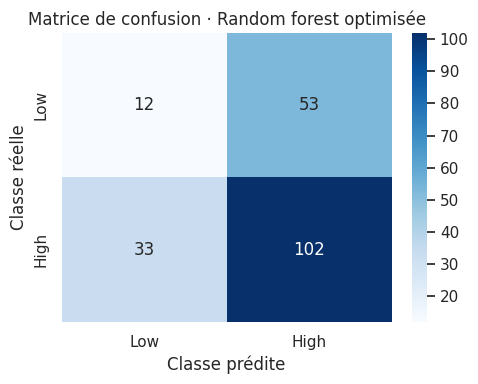

In [15]:
afficher_matrice(y_test, y_pred_rf, "Matrice de confusion · Random forest optimisée")

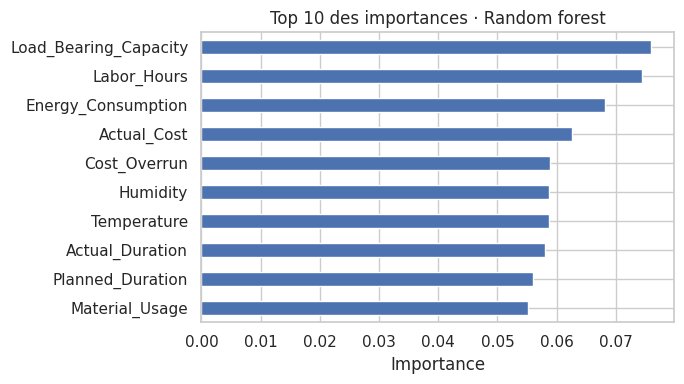

In [16]:
feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()
importances = best_rf.named_steps["classifier"].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)

feat_imp.sort_values().plot(kind="barh", figsize=(7, 4))
plt.title("Top 10 des importances · Random forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

**Attention à l'interprétation** : un modèle qui ne fait pas mieux que le hasard répartit ses « importances » sur du bruit. Ce classement ne doit donc pas être lu comme une liste de facteurs de risque réels.

## 6. Comparaison de tous les modèles

Les quatre modèles sont évalués avec **exactement** les mêmes variables, le même découpage et la même validation croisée à 5 plis. La régression logistique a besoin de variables à la même échelle : on ajoute donc une standardisation des variables numériques pour elle.

In [17]:
preprocessor_lr = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("num", StandardScaler(), numeric_features),
    ],
    verbose_feature_names_out=False,
)

modeles = {
    "Baseline naïve (toujours High)": DummyClassifier(strategy="most_frequent"),
    "Régression logistique": Pipeline([
        ("preprocessor", preprocessor_lr),
        ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000)),
    ]),
    "Arbre de décision": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(max_depth=10, class_weight="balanced", random_state=42)),
    ]),
    "Random forest optimisée": best_rf,
}

lignes_cv, lignes_test = [], []
for nom, modele in modeles.items():
    scores = cross_validate(modele, X_train, y_train, cv=cv, scoring=SCORING)
    lignes_cv.append({
        "Modèle": nom,
        "F1 macro (CV)": round(scores["test_f1_macro"].mean(), 3),
        "MCC (CV)": round(scores["test_mcc"].mean(), 3),
        "Accuracy (CV)": round(scores["test_accuracy"].mean(), 3),
    })
    modele.fit(X_train, y_train)
    lignes_test.append(evaluer(nom, y_test, modele.predict(X_test)))

comparaison_cv = pd.DataFrame(lignes_cv).set_index("Modèle")
comparaison_test = pd.DataFrame(lignes_test).set_index("Modèle")

print("Validation croisée (5 plis, jeu d'entraînement)")
display(comparaison_cv)
print("Jeu de test (200 projets)")
display(comparaison_test)

Validation croisée (5 plis, jeu d'entraînement)


,F1 macro (CV),MCC (CV),Accuracy (CV)
Modèle,,,
Baseline naïve (toujours High),0.402,0.000,0.672
Régression logistique,0.456,-0.061,0.474
Arbre de décision,0.480,-0.019,0.511
Random forest optimisée,0.525,0.073,0.619


Jeu de test (200 projets)


,F1 macro,MCC,Accuracy
Modèle,,,
Baseline naïve (toujours High),0.403,0.000,0.675
Régression logistique,0.512,0.045,0.535
Arbre de décision,0.454,0.009,0.455
Random forest optimisée,0.461,-0.067,0.570


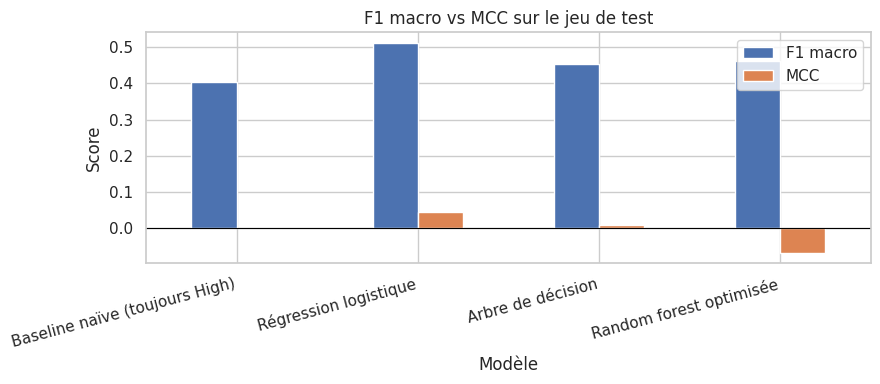

In [18]:
comparaison_test[["F1 macro", "MCC"]].plot(kind="bar", figsize=(9, 4))
plt.axhline(0, color="black", linewidth=0.8)
plt.title("F1 macro vs MCC sur le jeu de test")
plt.ylabel("Score")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## 7. Conclusion

- **Aucun modèle ne bat la baseline naïve.** Le MCC reste proche de 0 pour tous les modèles : leurs prédictions ne sont pas meilleures que le hasard.
- **Le F1 macro peut être trompeur.** Au fil des itérations du projet (passage à 2 classes, SMOTE, GridSearch, class_weight), le F1 est passé de 0,29 à 0,56 dans la présentation, alors que le MCC n'a jamais décollé de 0. Ces gains venaient des réglages de rééquilibrage, qui déplacent les prédictions entre les classes, et non d'une meilleure compréhension du risque.
- **La cause est dans les données, pas dans le modèle.** Comme l'a montré l'EDA, les variables sont générées aléatoirement et indépendamment du risque. Aucun algorithme ne peut apprendre une relation qui n'existe pas.

### Limites et pistes

- **Changer la matière plutôt que complexifier le modèle** : travailler sur des données réelles de chantiers (historique d'entreprise, bases d'accidents du travail, suivis de chantier).
- **Penser au moment de la prédiction** : pour identifier les chantiers à risque *en amont*, les coûts et durées réels (`Actual_Cost`, `Actual_Duration`, `Cost_Overrun`, `Schedule_Deviation`) ne sont pas encore connus. Sur des données réelles, il faudrait les exclure pour éviter une fuite temporelle.
- **Question métier à approfondir** : quel coût (d'audit, de retard) est-on prêt à accepter pour réduire un risque d'accident grave ? La réponse orienterait le choix entre recall et precision.